___

# <font color= #99C8F5> **Predicción del Tipo de Cambio en Banxico** </font>
#### <font color= #2E9AFE> `Modelos no Lineales para Pronósticos`</font>
<Strong> Daniela De la Torre, Samantha Sánchez, Sofía Maldonado & Viviana Toledo </Strong>

_04/03/2026._

___

# <font color= #99C8F5> **Librerías y Cargado de Datos** </font>

In [21]:
# Generales
import numpy as np
import pandas as pd
import banxicoapi
import os
from dotenv import load_dotenv

# Visualización
import matplotlib.pyplot as plt
import plotly.graph_objects as go

# Preprocesamiento
import holidays

# Pruebas Estadísticas
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Modelo
from statsmodels.tsa.statespace.sarimax import SARIMAX

Para iniciar, nos conectaremos a la API del Banco de México (Banxico) y extraeremos los datos del tipo de cambio entre el peso mexicano y el dólar.

In [22]:
# Get the API KEY
load_dotenv()
API_KEY = os.getenv('API_KEY')

# Connect to Banxico using its library
API = banxicoapi.BanxicoApi(API_KEY)

In [23]:
# Seleccionamos los datos que requerimos (Tipo de Cambio entre el peso y el dólar)
series = ["SF43718"]
response = API.get(series)

df = pd.DataFrame(response[0]['datos'])

df.head()

,fecha,dato
0,12/11/1991,3.0735
1,13/11/1991,3.0712
2,14/11/1991,3.0718
3,15/11/1991,3.0684
4,18/11/1991,3.0673


In [24]:
# Renombrar columnas y convertir tipos
df.rename(columns={'fecha':'Fecha','dato':'Valor'}, inplace=True)
df['Fecha'] = pd.to_datetime(df['Fecha'], format='%d/%m/%Y')            # Fecha a formato datetime
df['Valor'] = pd.to_numeric(df['Valor'], errors='coerce')               # Tipo de dato numérico (float)
df.set_index('Fecha', inplace=True)                                     # Definir la fecha como índice

In [25]:
df.head()

,Valor
Fecha,
1991-11-12,3.0735
1991-11-13,3.0712
1991-11-14,3.0718
1991-11-15,3.0684
1991-11-18,3.0673


# <font color= #99C8F5> **Visualización** </font>

In [26]:
# Index date column
df.index.name = 'Fecha'

# Visualize series
fig = go.Figure()
fig.add_trace(go.Scatter(x=df.index, y=df.Valor, mode='lines', name='MXN: USD'))

fig.update_layout(
    title='Cambio MXN-USD',
    xaxis_title='Fecha',
    yaxis_title='MXN: USD'
)
fig.show()

Debido a que el cambio de MXN a USD es bastante variable, decidimos filtrar el dataset. Nuestro objetivo es predecir la semana del 04/mar/2026 al 13/mar/2026, tomaremos exclusivamente los **datos del año 2025**. 

In [27]:
# Filter dataset
df = df.loc['2025-01-01':]

# Visualize series
fig = go.Figure()
fig.add_trace(go.Scatter(x=df.index, y=df.Valor, mode='lines', name='MXN: USD'))

fig.update_layout(
    title='Cambio MXN-USD',
    xaxis_title='Fecha',
    yaxis_title='MXN: USD'
)
fig.show()

Observando las gráficas, hay algunos eventos puntuales donde la paridad del peso y dólar varía significativamente:

- 4 de Marzo 2025. Alza. A la par, comienzan las guerras de aranceles de Trump [1].

- 14 de Marzo 2025. Baja. Trump amenaza a la Unión Europea de imponer aranceles [1].

- 3 de Abril 2025. Baja. Tarifas arancelarias de Trump a vehículos importados [1].

- 9 al 22 de Abril 2025. Baja. Trump responde a las represalias de otros países con más aranceles :) Se relaja el 29 de Abril [1].

- 16 al 23 de Junio 2025. Alza. Conflictos entre Irán e Israel, donde interviene Estados Unidos [2].

- 2 de Marzo 2026. Trump inicia una guerra contra Irán...

Por lo tanto, se implementará una variable exógena que tenga en cuenta la especulación producto de eventos internacionales. Donde 1 representa una posible subida, -1 una posible bajada y 0 como valor default.

# <font color= #99C8F5> **Preprocesamiento** </font>

Primero, se creará la variable exógena de especulación en base a conflictos internacionales:

$$
X_t =
\begin{cases}
1 & \text{si ocurre un evento que fortalece al USD (especulación positiva)} \\
-1 & \text{si ocurre un evento que debilita al USD (especulación negativa)} \\
0 & \text{si no ocurre ningún evento relevante}
\end{cases}
$$

In [28]:
# Declarar variable exógena
df['speculation'] = 0

# Guerra de Aranceles
df.loc['2025-03-04', 'speculation'] = 1                   # Canada and Mexico tariffs are applied
df.loc['2025-03-05':'2025-03-14', 'speculation'] = -1     # Trump's back-and-fort show w tariffs
df.loc['2025-03-26', 'speculation'] = -1                  # Trump announces tariffs to vehicles
df.loc['2025-04-02':'2025-04-03', 'speculation'] = -1     # Trump announces reciprocal tariffs & applies vehicle tariffs
df.loc['2025-04-09':'2025-04-29', 'speculation'] = -1     # Trump applies reciprocal tariffs and then relaxes on Apr 29

# Tensiones políticas de Estados Unidos
df.loc['2025-09-24':'2025-11-04', 'speculation'] = -1     # Possible US government shutdown [3]

# Irán-Israel-Estados Unidos (nightmare blunt rotation) (why is war even profitable...)
df.loc['2025-06-13':'2025-06-24', 'speculation'] = 1
df.loc['2026-03-02':, 'speculation'] = 1

In [29]:
df.head()

,Valor,speculation
Fecha,,
2025-01-02,20.6917,0
2025-01-03,20.6708,0
2025-01-06,20.3195,0
2025-01-07,20.3440,0
2025-01-08,20.3823,0


Ahora, realizaremos un train-test-split del 95% train y 5% test:

In [30]:
# Establish train size
train_size = 0.95
split_index = int(len(df) * train_size)

# Train-Test-Split
train_df = df.iloc[:split_index]
test_df = df.iloc[split_index:]

print(f"Train Size: {len(train_df)} days\n")
print(f"Test Size: {len(test_df)} days")

Train Size: 279 days

Test Size: 15 days


# <font color= #99C8F5> **Pruebas Estadísticas** </font>

## <font color= #70A9E0> &ensp; • **Estacionariedad** </font>

In [31]:
# ADF Test
val_dickey_fuller = adfuller(train_df['Valor'].dropna())
# KPSS Test
kpss_test = kpss(train_df['Valor'].dropna())

# Results
print(f"Dickey-Fuller: {val_dickey_fuller[1]}")
print(f"KPSS: {kpss_test[1]}")

Dickey-Fuller: 0.8678594693763668
KPSS: 0.01


/tmp/ipykernel_6497/3255242365.py:4: InterpolationWarning:

The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.




Ya que la prueba Dickey-Fuller retorna un valor mayor a 0.05, y la prueba KPSS retorna un valor menor a 0.05, se define que la serie no es estacionaria

Vamos a probar haciendo una diferenciación

In [32]:
# Apply first differentiation
train_df['diff_1'] = train_df['Valor'].diff()

# ADF Test
val_dickey_fuller = adfuller(train_df['diff_1'].dropna())
# KPSS Test
kpss_test = kpss(train_df['diff_1'].dropna())

# Results
print(f"Dickey-Fuller: {val_dickey_fuller[1]}")
print(f"KPSS: {kpss_test[1]}")

Dickey-Fuller: 0.0
KPSS: 0.1


/tmp/ipykernel_6497/379503198.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ipykernel_6497/379503198.py:7: InterpolationWarning:

The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.




Con una diferenciación ya es estacionaria

## <font color= #70A9E0> &ensp; • **Orden p, q y P, Q, s** </font>

Para establecer el orden de los componentes autoregresivos y de media móvil, se evaluarán las gráficas de ACF y PACF.

Resultados de Estacionariedad:
--- Prueba ADF para: Valor con 1era Diferenciación ---
ADF Statistic: -19.7903
p-value: 0.0000
✅ La serie es ESTACIONARIA (Podemos modelar)


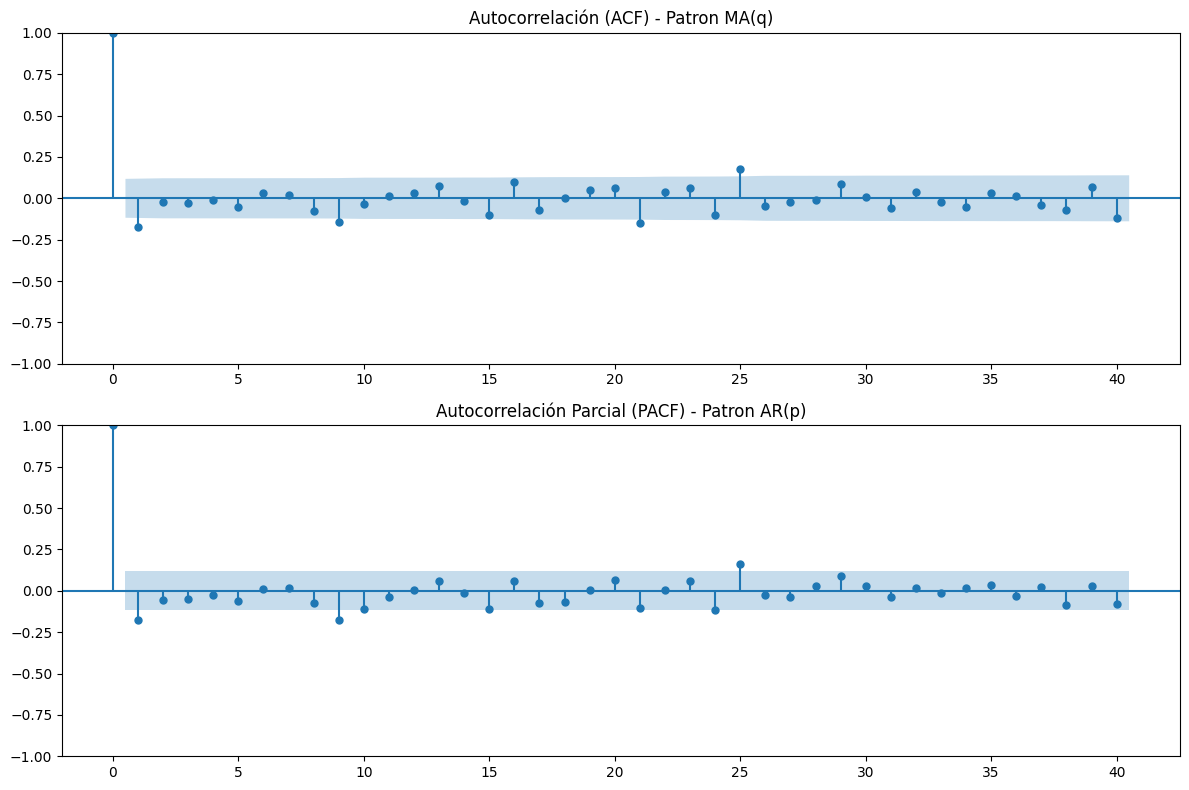

In [33]:
# Prueba de Dickey-Fuller Aumentada (ADF)
def run_adf(series, name):
    result = adfuller(series.dropna())
    print(f'--- Prueba ADF para: {name} ---')
    print(f'ADF Statistic: {result[0]:.4f}')
    print(f'p-value: {result[1]:.4f}')
    if result[1] < 0.05:
        print("✅ La serie es ESTACIONARIA (Podemos modelar)")
    else:
        print("❌ La serie NO es estacionaria (Necesita más diferenciación)")

print("Resultados de Estacionariedad:")
run_adf(train_df['diff_1'], "Valor con 1era Diferenciación")

# Usamos la serie diferenciada porque es la que entra al modelo
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
plot_acf(train_df['diff_1'].dropna(), lags=40, ax=ax1, title="Autocorrelación (ACF) - Patron MA(q)")
plot_pacf(train_df['diff_1'].dropna(), lags=40, ax=ax2, title="Autocorrelación Parcial (PACF) - Patron AR(p)")
plt.tight_layout()
plt.show()

Las gráficas de PACF y ACF sugieren que $p=1$ y $q=1$. En cuanto al componente estacional, no parece existir una temporalidad en el año de 2025 hasta ahora.

# <font color= #99C8F5> **Modelado** </font>

Debido a que las gráficas de PACF y ACF no otorgaban mucha información para la serie de tiempo, se intentaron múltiples combinaciones para el orden del modelo. De tal manera que el modelo queda definido como:

$$
SARIMAX(6,1,1)(0,1,0)_7 * x_\text{especulación}
$$

In [115]:
# Definir la variable exógena
exog = train_df[['speculation']]

# Ajustar el modelo SARIMAX
modelo = SARIMAX(train_df['Valor'], 
                 order = (6,1,1), 
                 seasonal_order = (0,1,0,7),
                 exog = exog)
# Entrenar el modelo
resultado = modelo.fit(disp=False)

# Resumen del ajuste 
print(resultado.summary())  

/home/vivienne/anaconda3/envs/time-series/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.

/home/vivienne/anaconda3/envs/time-series/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.



                                     SARIMAX Results                                      
Dep. Variable:                              Valor   No. Observations:                  279
Model:             SARIMAX(6, 1, 1)x(0, 1, [], 7)   Log Likelihood                 146.559
Date:                            Wed, 04 Mar 2026   AIC                           -275.118
Time:                                    15:27:03   BIC                           -242.699
Sample:                                         0   HQIC                          -262.102
                                            - 279                                         
Covariance Type:                              opg                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
speculation     0.1171      0.017      6.960      0.000       0.084       0.150
ar.L1          -0.7964      0.10

/home/vivienne/anaconda3/envs/time-series/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals



El modelo obtuvo valores bajos de AIC y BIC, lo que sugiere que el ajuste es bueno. Además, la variable exógena es relevante.

In [116]:
# Predecir los próximos 9 días (5 al 13 de marzo de 2026)
exog_future = pd.DataFrame({'speculation': [1]*9})                  # Variable exógena = 1
pronostico = resultado.get_forecast(steps=9, exog=exog_future)      # Realizar el pronóstico
pred_mean = pronostico.predicted_mean

# Crear índice de fechas para el pronóstico (a partir del último día observado)
fechas_pred = pd.date_range(start=df.index[-1] + pd.Timedelta(days=1), periods=9, freq='D')

# Crear DataFrame con Fecha y Pronóstico
df_pred = pd.DataFrame({'Fecha': fechas_pred, 'Pronóstico': pred_mean.values})

# Exportar las predicciones a un archivo Excel
df_pred.to_excel("predicciones_mar5_13_2026.xlsx", index=False)


/home/vivienne/anaconda3/envs/time-series/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning:

No supported index is available. Prediction results will be given with an integer index beginning at `start`.

/home/vivienne/anaconda3/envs/time-series/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning:

No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.



In [117]:
fig = go.Figure()
# Serie histórica observada
fig.add_trace(go.Scatter(x=df.index, y=df['Valor'], mode='lines', name='Observado'))
# Pronóstico futuro
fig.add_trace(go.Scatter(x=df_pred['Fecha'], y=df_pred['Pronóstico'], mode='lines', name='Pronóstico'))
fig.update_layout(title='Tipo de cambio MXN/USD (FIX): Observado vs Pronóstico',
                  xaxis_title='Fecha', yaxis_title='Tipo de cambio (FIX)')
fig.show()


# <font color= #99C8F5> **Referencias** </font>

[1] Grantham-Philips, W. (2025, 26 de mayo). _A timeline of Trump's tariff actions so far_. _PBS News_. https://www-pbs-org.translate.goog/newshour/economy/a-timeline-of-trumps-tariff-actions-so-far?_x_tr_sl=en&_x_tr_tl=es&_x_tr_hl=es&_x_tr_pto=tc

[2] Wikipedia Contributors. (2026, 4 de marzo). _Twelve-Day War_. _Wikipedia_. https://en.wikipedia.org/wiki/Twelve-Day_War

[3] Zurcher, A. (2025, 30 de septiembre). _US shutdown looms after Trump and Democrats end meeting without a deal_. _BBC_. https://www.bbc.com/news/articles/c2kn3n315lko